# Phase 1 — Data Understanding & Exploration
### WPF Python Advanced · Condition Monitoring of Hydraulic Systems
**Target variable:** `Hydraulic accumulator` (4 classes: 130 / 115 / 100 / 90 bar)

This notebook performs the exploratory data analysis (EDA) for Phase 1. The goal is to
understand the dataset well enough to plan signal preprocessing (Phase 2) and modelling (Phase 3).

**Structure**
1. Setup & data loading
2. Target variable analysis
3. Sensor overview & raw signal inspection
4. Cycle-level feature extraction (simple summary statistics)
5. Which sensors discriminate the target? (ANOVA-F + Mutual Information)
6. Correlation analysis (redundant sensors)
7. **Temporal structure / drift — a critical finding**
8. Hypotheses & plan for Phases 2 and 3

Note: AI was used to to clean up the Notebook and add better comments

## 1. Setup & data loading

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.width", 200)

# path to the dataset folder on my laptop
data = "condition+monitoring+of+hydraulic+systems"

# the dataset has 17 sensors in total
sensors = ["PS1", "PS2", "PS3", "PS4", "PS5", "PS6", "EPS1",
           "FS1", "FS2",
           "TS1", "TS2", "TS3", "TS4",
           "VS1", "CE", "CP", "SE"]

# each sensor records at a different speed
# pressure sensors -> 100 readings per second -> 6000 per cycle
# flow sensors -> 10 readings per second -> 600 per cycle
# temperature + others -> 1 reading per second -> 60 per cycle
sampling_Hz = {}
for s in ["PS1", "PS2", "PS3", "PS4", "PS5", "PS6", "EPS1"]:
    sampling_Hz[s] = 100
for s in ["FS1", "FS2"]:
    sampling_Hz[s] = 10
for s in ["TS1", "TS2", "TS3", "TS4", "VS1", "CE", "CP", "SE"]:
    sampling_Hz[s] = 1

print(sampling_Hz)

{'PS1': 100, 'PS2': 100, 'PS3': 100, 'PS4': 100, 'PS5': 100, 'PS6': 100, 'EPS1': 100, 'FS1': 10, 'FS2': 10, 'TS1': 1, 'TS2': 1, 'TS3': 1, 'TS4': 1, 'VS1': 1, 'CE': 1, 'CP': 1, 'SE': 1}


In [8]:
# profile.txt contains the condition labels for each 60s cycle
# it has no header so I need to name the columns myself
# the file is tab-separated (not comma-separated)
profile_header = ["Cooler", "Valve", "Pump_leakage", "Accumulator", "Stable"]

profile = pd.read_csv(data + "/profile.txt", sep="	", header=None, names=profile_header)  # used AI to find out sep="	" means tab-separated

# checking how many cycles we have and what the data looks like
print("profile shape:", profile.shape)
profile.head()


profile shape: (2205, 5)


,Cooler,Valve,Pump_leakage,Accumulator,Stable
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


We only model the **Accumulator** column. The four classes (in *bar*) are:
| value | meaning |
|---|---|
| 130 | optimal pressure |
| 115 | slightly reduced |
| 100 | severely reduced |
| 90  | close to total failure |

## 2. Target variable analysis

In [18]:
#class distribution for all 5 condition columns (it is already noted in documentation.txt)
# I want to check the class distribution for Accumulator condition columns (it is already noted in documentation.txt)

y = profile["Accumulator"]
counts = y.value_counts().sort_index()
print("Class counts:\n", counts)
print("\nProportions (%):\n", (y.value_counts(normalize=True).sort_index()*100).round(1)) # AI: used normalize=True to get percentages instead of raw counts


Class counts:
 Accumulator
90     808
100    399
115    399
130    599
Name: count, dtype: int64

Proportions (%):
 Accumulator
90     36.6
100    18.1
115    18.1
130    27.2
Name: proportion, dtype: float64


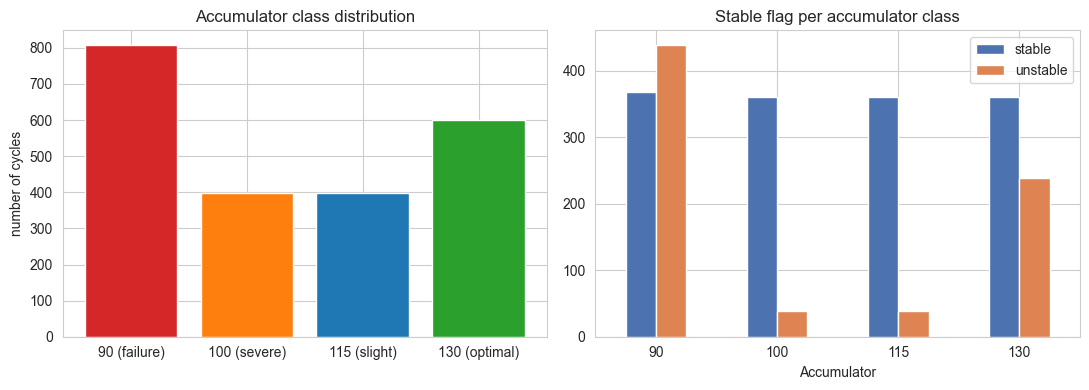

In [22]:
# AI generated the diagram code below
# my reasoning: I wanted two figures —
#   1) to see how many cycles each class has (to confirm the imbalance I noticed)
#   2) to see how the stable flag is spread across classes (to decide later if I should drop unstable cycles)

# I noticed class 90 shows up a lot more than 100 and 115
# this means the dataset is imbalanced, which affects which metrics I should use later (The affect of failure would be more than others for learning algorithm)

# color and label for each accumulator class
labels = {90: "90 (failure)", 100: "100 (severe)", 115: "115 (slight)", 130: "130 (optimal)"}
colors = {90: "#d62728", 100: "#ff7f0e", 115: "#1f77b4", 130: "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# left plot: how many cycles belong to each class
bar_labels = [labels[c] for c in counts.index]
bar_colors = [colors[c] for c in counts.index]
axes[0].bar(bar_labels, counts.values, color=bar_colors)
axes[0].set_title("Accumulator class distribution")
axes[0].set_ylabel("number of cycles")

# right plot: how many cycles per class were stable vs unstable
ct = pd.crosstab(profile["Accumulator"], profile["Stable"])
ct.plot(kind="bar", stacked=False, ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].set_title("Stable flag per accumulator class")
axes[1].legend(["stable", "unstable"])
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [24]:
# I want to know how many cycles were stable vs unstable for each accumulator class
# stable = 0, unstable = 1 (from the documentation)

accumulator_classes = sorted(profile["Accumulator"].unique())

for cls in accumulator_classes:
    stable   = ((profile["Accumulator"] == cls) & (profile["Stable"] == 0)).sum()
    unstable = ((profile["Accumulator"] == cls) & (profile["Stable"] == 1)).sum()
    print(f"Class {cls} bar: stable = {stable}, unstable = {unstable}")


Class 90 bar: stable = 369, unstable = 439
Class 100 bar: stable = 360, unstable = 39
Class 115 bar: stable = 360, unstable = 39
Class 130 bar: stable = 360, unstable = 239


**Observation:** The *stable flag* is very unevenly distributed. Classes 100 and 115 are
almost always recorded under stable conditions, whereas 90 and 130 contain many "unstable"
cycles. We should decide in Phase 2 whether to drop, keep, or separately analyse unstable cycles.

## 3. Sensor overview & raw signal inspection

In [26]:
# each sensor is stored as a separate .txt file
# each row is one 60s cycle, each column is one measurement
# I wrote this function to make loading any sensor easier
def load_sensor(name):
    return np.loadtxt(data + "/" + name + ".txt")

# I am testing with PS5 first to make sure the function works
# PS5 is a 100 Hz sensor so it should have 6000 columns (100 x 60 seconds)
ps5 = load_sensor("PS5")
print("PS5 shape:", ps5.shape)
print("expected: 2205 cycles x 6000 timepoints (100 Hz x 60 s)")


PS5 shape: (2205, 6000) -> 100 Hz x 60 s


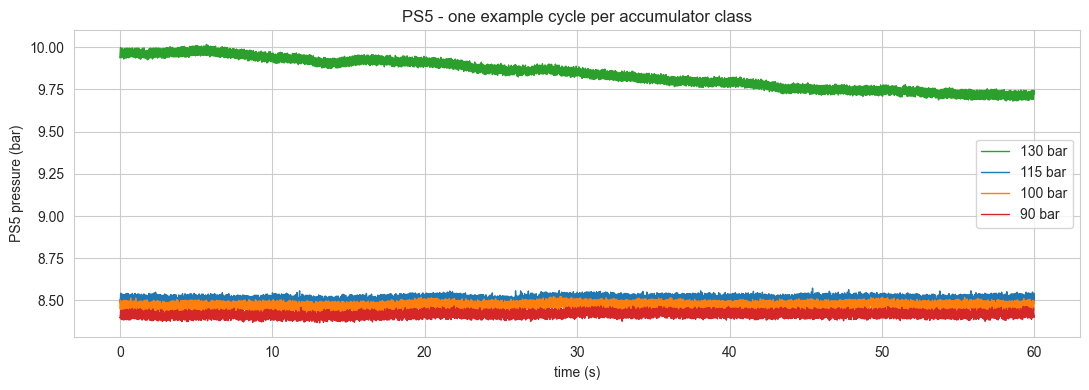

In [28]:
# my idea: I wanted to see if the raw pressure signal looks different
# depending on the accumulator condition — if it does, the sensor is useful
# I picked one cycle from each class and plotted them together for comparison
# AI generated the plot code below

# create the time axis in seconds (PS5 records 100 times per second)
t = np.arange(ps5.shape[1]) / sampling_Hz["PS5"]

fig, ax = plt.subplots(figsize=(11, 4))

for cls in [130, 115, 100, 90]:
    # find the first cycle that belongs to this class
    first_cycle_index = np.where(y.values == cls)[0][0]
    ax.plot(t, ps5[first_cycle_index], color=colors[cls], lw=1, label=f"{cls} bar")

ax.set_xlabel("time (s)")
ax.set_ylabel("PS5 pressure (bar)")
ax.set_title("PS5 - one example cycle per accumulator class")
ax.legend()

plt.tight_layout()
plt.show()


**Observation:** Each cycle is a repeating *load cycle*. The signal is highly structured
(not stationary), so simple global statistics will lose information — in Phase 2 we will use a
dedicated time-series feature library (e.g. tsfresh / TSFEL) to capture shape, not just level.

## 4. Cycle-level feature extraction (simple summary statistics)

For EDA we collapse each 60 s cycle into a few summary numbers (mean, std, min, max).
This is **not** the final feature set — it is a fast, interpretable view that lets us compare
all 17 sensors on equal footing and form hypotheses.

In [ ]:
# instead of working with the raw 6000-column signals directly,
# I want to summarize each 60s cycle into 4 simple numbers per sensor:
# mean, std, min, max
# this makes it much easier to compare sensors and classes

# I will store the results in 4 separate dictionaries, one per statistic
mean_per_sensor = {}
std_per_sensor  = {}
min_per_sensor  = {}
max_per_sensor  = {}

for sensor in sensors:
    data_matrix = load_sensor(sensor)   # shape: (2205 cycles, timepoints)

    # axis=1 means calculate across columns (across time), one result per row (per cycle)
    mean_per_sensor[sensor] = data_matrix.mean(axis=1)
    std_per_sensor[sensor]  = data_matrix.std(axis=1)
    min_per_sensor[sensor]  = data_matrix.min(axis=1)
    max_per_sensor[sensor]  = data_matrix.max(axis=1)

# turn the dictionaries into dataframes so I can work with them more easily
df_mean = pd.DataFrame(mean_per_sensor)
df_std  = pd.DataFrame(std_per_sensor)

# add the accumulator class label to df_mean so I can group by class later
df_mean["Accumulator"] = y.values

print("df_mean shape:", df_mean.shape)  # should be 2205 rows x 18 columns (17 sensors + Accumulator label)
df_mean.head()


Cycle-mean table: (2205, 18)


,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,Accumulator
0,160.673492,109.466914,1.991475,0.0,9.842169,9.728098,2538.929167,6.709815,10.304592,35.621983,40.978767,38.471017,31.745250,0.576950,39.601350,1.862750,59.157183,130
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,2531.498900,6.715315,10.403098,36.676967,41.532767,38.978967,34.493867,0.565850,25.786433,1.255550,59.335617,130
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,2519.928000,6.718522,10.366250,37.880800,42.442450,39.631950,35.646150,0.576533,22.218233,1.113217,59.543150,130
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337429,2511.541633,6.720565,10.302678,38.879050,43.403983,40.403383,36.579467,0.569267,20.459817,1.062150,59.794900,130
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,2503.449500,6.690308,10.237750,39.803917,44.332750,41.310550,37.427900,0.577367,19.787017,1.070467,59.455267,130


In [ ]:
# I want to see the average value of each sensor per accumulator class
# if the values are clearly different between classes, that sensor is useful for prediction

# groupby groups the rows by accumulator class, then mean() calculates the average per group
# .T transposes the table so sensors are rows and classes are columns - easier to read (Suggested by AI)
# .round(3) just limits the decimal places so the table is not too messy
df_mean.groupby("Accumulator").mean().T.round(3)


Accumulator,90,100,115,130
PS1,160.634,162.394,161.526,158.321
PS2,109.471,111.339,110.422,107.258
PS3,1.795,1.665,1.713,1.782
PS4,2.223,3.364,3.137,2.243
PS5,9.311,9.140,9.143,8.993
PS6,9.220,9.058,9.060,8.916
EPS1,2501.651,2522.992,2514.496,2456.270
FS1,6.291,5.785,5.949,6.516
FS2,9.740,9.603,9.633,9.569
TS1,43.471,45.875,45.710,47.570


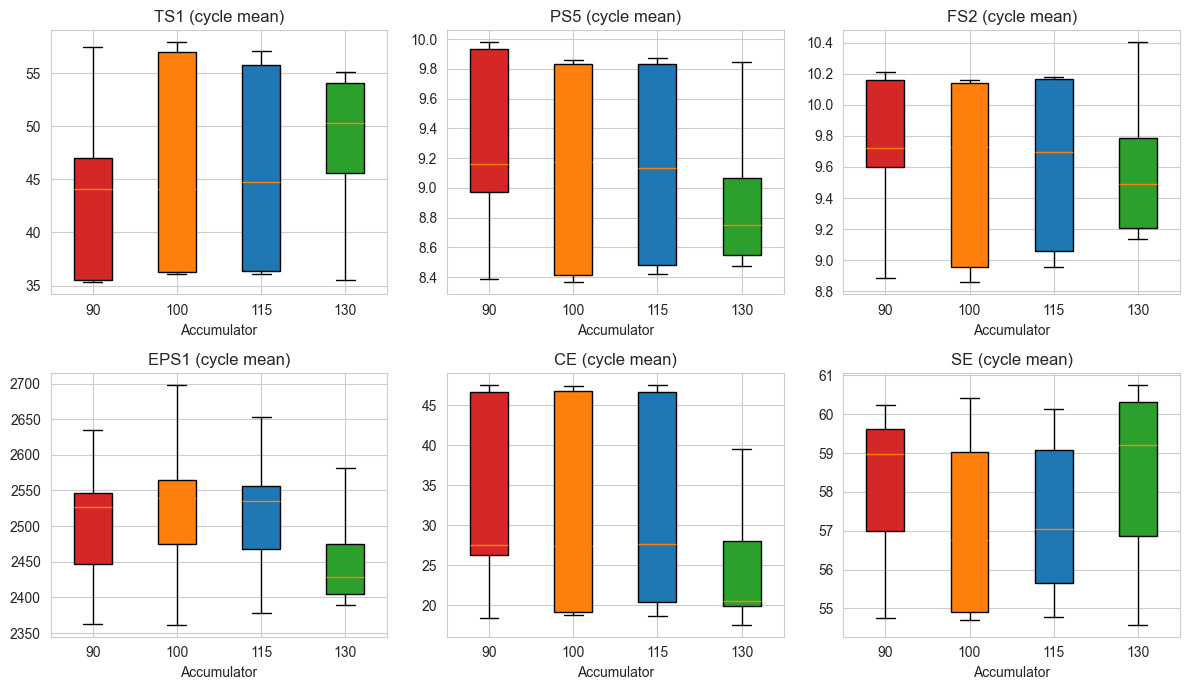

In [32]:
# my idea: I wanted to pick the sensors that looked most promising from the mean table
# and see if their values are clearly different between accumulator classes
# a boxplot is good for this because it shows the spread of values, not just the average
# AI generated the plot code below

# the 6 sensors I picked as most interesting based on the mean table above
top_sensors = ["TS1", "PS5", "FS2", "EPS1", "CE", "SE"]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, sensor in zip(axes.flat, top_sensors):
    # group the cycle-mean values by accumulator class
    grouped_data = [df_mean[sensor][y == cls] for cls in [90, 100, 115, 130]]

    # draw the boxplot — patch_artist=True allows filling boxes with color
    # showfliers=False hides outlier dots to keep the plot clean
    bp = ax.boxplot(grouped_data, tick_labels=["90", "100", "115", "130"],
                    patch_artist=True, showfliers=False)

    # color each box by its accumulator class
    for patch, cls in zip(bp["boxes"], [90, 100, 115, 130]):
        patch.set_facecolor(colors[cls])

    ax.set_title(f"{sensor} (cycle mean)")
    ax.set_xlabel("Accumulator class")

plt.tight_layout()
plt.show()


**Observation:**

Looking at the 6 boxplots, no single sensor can cleanly separate all 4 classes on its own.

**PS5 and EPS1** both show that class 130 (optimal) sits clearly below the other three classes — 
this makes physical sense because a healthy accumulator buffers pressure better, 
which results in lower average pressure and power readings. 
However, classes 90, 100, and 115 still overlap heavily in both sensors.

**TS1** separates class 90 (near failure) at the lower end, 
but classes 100, 115, and 130 all overlap significantly. 
I will investigate in Section 7 whether this separation is actually caused by 
the accumulator condition or just by the temperature drift during the experiment.

**FS2, CE, and SE** show the most overlap across all classes and are the least useful on their own.

The hardest pair to separate is **100 vs 115** — they overlap in every single sensor shown here. 
This will likely be the biggest challenge for the model in Phase 3.

## 5. Which sensors discriminate the target?

We rank sensors with two complementary univariate methods:
- **ANOVA F-statistic** — captures *linear* mean differences between classes.
- **Mutual information** — captures *any* (also non-linear) dependency.

In [39]:
from sklearn.feature_selection import f_classif, mutual_info_classif

# I want to rank all sensors by how useful they are for predicting the accumulator class
# I will use two different methods and compare them :
#   1) ANOVA F-statistic: checks if the class means are significantly different
#   2) Mutual Information: measures any kind of relationship, not just linear ones (Method where suggested by AI)

# build a feature table using mean and std of each sensor
# I use both mean and std because the spread of values might also carry useful information
feature_cols = {}
for s in sensors:
    feature_cols[f"{s}_mean"] = df_mean[s]
    feature_cols[f"{s}_std"]  = df_std[s]

X = pd.DataFrame(feature_cols)

# run both ranking methods
F_scores, p_values = f_classif(X, y)
mi_scores = mutual_info_classif(X, y, random_state=0)  # AI: random_state=0 for reproducibility

# combine results into one table for easy comparison
ranking = pd.DataFrame({
    "feature":     X.columns,
    "F_stat":      F_scores,
    "p_value":     p_values,
    "mutual_info": mi_scores
})

# sort by mutual information and show the top 12 most useful features
ranking.sort_values("mutual_info", ascending=False).head(12).round(4)


,feature,F_stat,p_value,mutual_info
18,TS1_mean,32.4091,0.0,0.8410
24,TS4_mean,32.9717,0.0,0.8348
22,TS3_mean,29.4663,0.0,0.8245
20,TS2_mean,33.0494,0.0,0.8149
8,PS5_mean,37.1359,0.0,0.7792
10,PS6_mean,37.4507,0.0,0.7622
16,FS2_mean,19.3998,0.0,0.7394
12,EPS1_mean,96.5947,0.0,0.5494
0,PS1_mean,78.5855,0.0,0.4729
2,PS2_mean,68.2902,0.0,0.4559


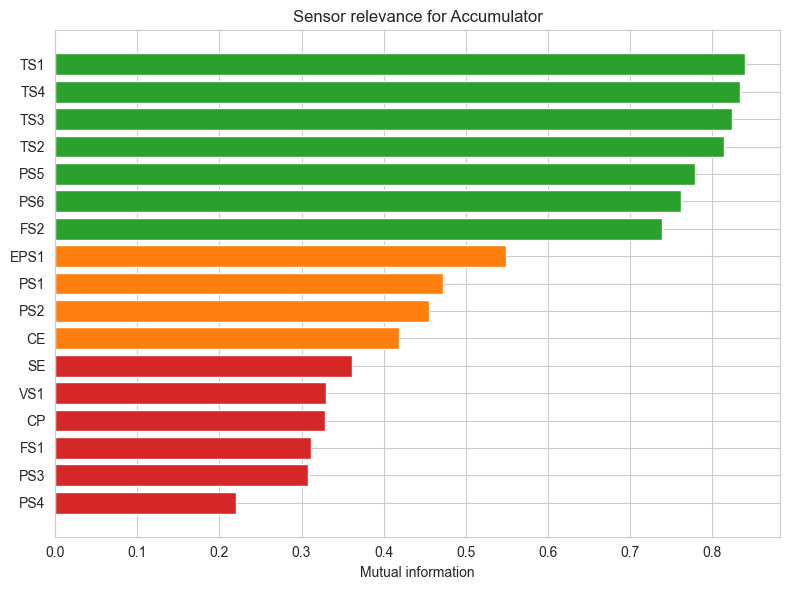

sensor
TS1     0.841
TS4     0.835
TS3     0.824
TS2     0.815
PS5     0.779
PS6     0.762
FS2     0.739
EPS1    0.549
PS1     0.473
PS2     0.456
CE      0.418
SE      0.361
VS1     0.330
CP      0.329
FS1     0.311
PS3     0.308
PS4     0.221
Name: mutual_info, dtype: float64

In [37]:
# the ranking table has one row per feature (e.g. TS1_mean, TS1_std)
# but I want one score per sensor, not per feature
# so I strip the _mean and _std suffix to get back to the sensor name
# then I take the max MI score across mean and std — whichever is more useful
ranking["sensor"] = ranking["feature"].str.replace("_mean", "").str.replace("_std", "")
sensor_mi = ranking.groupby("sensor")["mutual_info"].max().sort_values()

# color each bar by how informative the sensor is:
#   green  = MI > 0.6 → strong signal
#   orange = MI > 0.4 → moderate signal
#   red    = MI ≤ 0.4 → weak signal
fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = ["#2ca02c" if v > 0.6 else "#ff7f0e" if v > 0.4 else "#d62728"
              for v in sensor_mi.values]
ax.barh(sensor_mi.index, sensor_mi.values, color=bar_colors)
ax.set_xlabel("Mutual information")
ax.set_title("Sensor relevance for Accumulator")
plt.tight_layout()
plt.show()

# also print the ranked list so I can read the exact numbers
sensor_mi.sort_values(ascending=False).round(3)

**Hypothesis (relevant sensors):** TS1–TS4, PS5, PS6 and FS2 are the most informative;
PS3, PS4, FS1 and VS1 the least. This is our starting shortlist for the sensor-reduction task
in Phase 4 — but see the drift caveat below before trusting the temperature sensors.

## 6. Correlation analysis (redundant sensors)

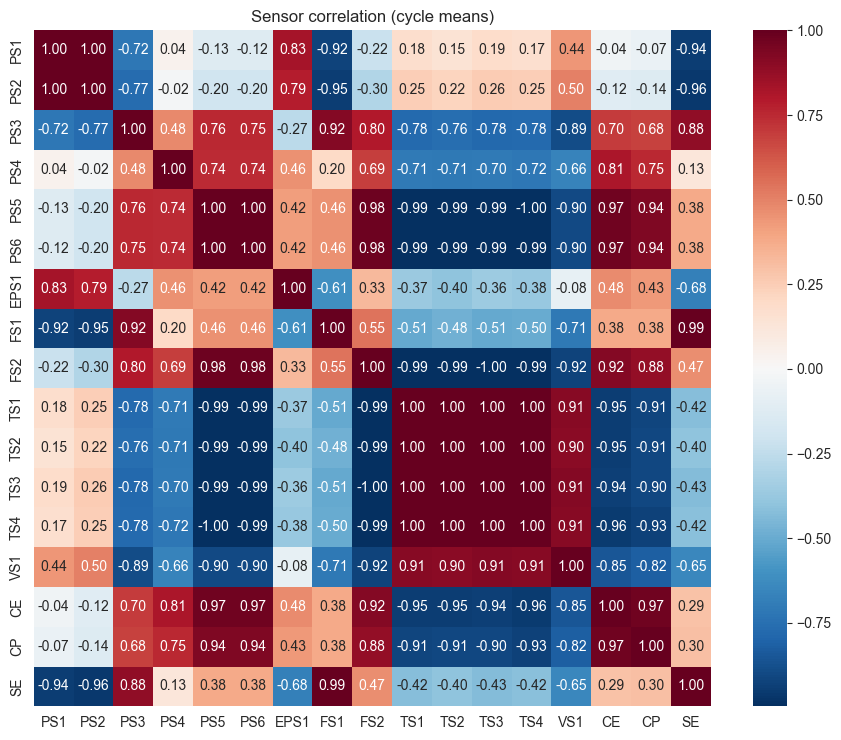

In [41]:
# I want to check which sensors are redundant — if two sensors move together,
# they carry the same information and I probably only need one of them in the model
# Pearson correlation: 1 = identical, 0 = unrelated, -1 = opposite

corr = df_mean[sensors].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Sensor correlation (cycle means)")
plt.tight_layout()
plt.show()

**Observation:** The four temperature sensors are mutually highly correlated, as are the
main pressure sensors. Strongly correlated sensors carry redundant information — important for
Phase 4, where we want the *minimum* sensor set: we likely need only one representative of each
correlated group.

## 7. Temporal structure / drift — a critical finding

Because the accumulator is a *pressure* device, it is suspicious that **temperature**
sensors are the single most discriminative signals. We therefore check whether sensor values
(and the labels themselves) depend on the **experiment order** (cycle index).

In [43]:
# I want to check if sensor readings change over the course of the experiment
# (not because of the accumulator condition, but just because time passed)
# to do this I create a simple cycle number: 0, 1, 2, ... 2204
profile["cycle_idx"] = np.arange(len(profile))

# for each sensor, I calculate how strongly its cycle-mean correlates with cycle number
# a high correlation means the sensor drifts over time, which is a problem
drift = {}
for s in sensors:
    drift[s] = np.corrcoef(df_mean[s], profile["cycle_idx"])[0, 1]

drift = pd.Series(drift).sort_values()
print("Correlation of each sensor with experiment order (closer to ±1 = more drift):")
print(drift.round(3))

Correlation of each sensor with experiment order (closer to ±1 = more drift):
TS4    -0.910
TS2    -0.907
TS1    -0.904
TS3    -0.899
VS1    -0.802
PS2    -0.097
PS1    -0.021
SE      0.237
FS1     0.323
EPS1    0.470
PS3     0.609
PS4     0.765
FS2     0.868
CP      0.903
CE      0.913
PS5     0.914
PS6     0.914
dtype: float64


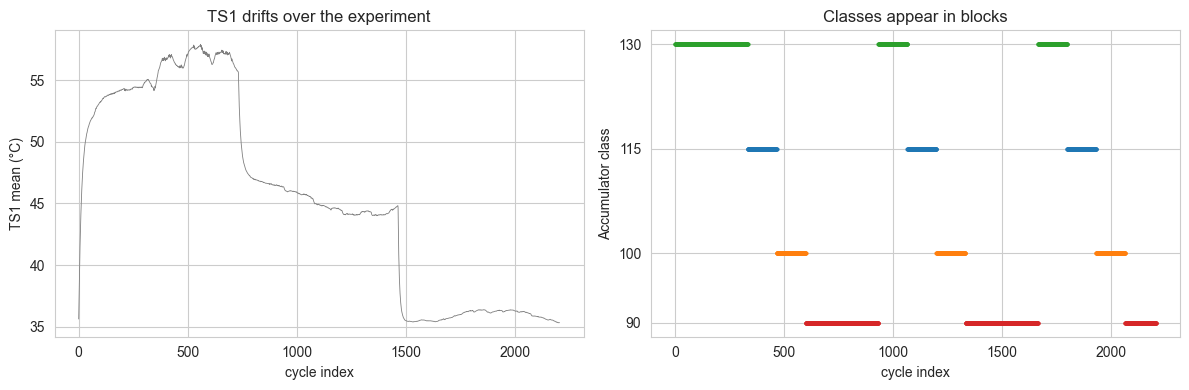

In [44]:
# two plots side by side to understand the drift problem visually:
#   left:  does TS1 slowly rise or fall as the experiment goes on?
#   right: are the accumulator classes mixed randomly, or recorded in blocks?
# if the classes appear in blocks AND a sensor drifts, that sensor is unreliable

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left plot: TS1 temperature over the course of the experiment
axes[0].plot(profile["cycle_idx"], df_mean["TS1"], lw=0.6, color="grey")
axes[0].set_xlabel("cycle index")
axes[0].set_ylabel("TS1 mean (°C)")
axes[0].set_title("TS1 drifts over the experiment")

# right plot: when was each accumulator class recorded?
# each dot is one cycle, colored by its class
for c in [90, 100, 115, 130]:
    mask = y.values == c
    axes[1].scatter(profile["cycle_idx"][mask], [c] * mask.sum(), s=4, color=colors[c])
axes[1].set_yticks([90, 100, 115, 130])
axes[1].set_xlabel("cycle index")
axes[1].set_ylabel("Accumulator class")
axes[1].set_title("Classes appear in blocks")

plt.tight_layout()
plt.show()

**Critical finding:** TS1 correlates with experiment order at r ≈ -0.90, and the classes
are recorded in repeating **blocks** rather than randomly interleaved. The rig warmed up and
later cooled in steps, so temperature partly encodes *when* a cycle was recorded, not the
accumulator's physical state.

**Consequences for later phases:**
- A purely random train/test split would **leak** this temporal structure and inflate scores.
  We should report results under a block-/group-aware split as well.
- The high ranking of temperature sensors must be treated with caution; pressure/flow sensors
  (PS5, PS6, FS2) are more physically plausible and should be prioritised for the minimal sensor
  set in Phase 4.

## 8. Hypotheses & plan for Phases 2 and 3

**Hypotheses (H):**
- **H1 — Relevant sensors:** PS5, PS6 and FS2 carry genuine, physically plausible information
  about accumulator pressure; TS1–TS4 are informative but partly confounded by thermal drift.
- **H2 — Redundancy:** The temperature group and the main pressure group are each internally
  redundant → one representative per group should suffice (good news for sensor reduction).
- **H3 — Class difficulty:** 100 vs 115 will be the hardest to separate (overlapping boxplots,
  both ~18% of data); 90 and 130 are easier.
- **H4 — Signal shape matters:** raw cycles are non-stationary, so shape-based features
  (not just mean/std) should improve separability.

**Plan — Phase 2 (Signal Preprocessing & Feature Engineering):**
- Down-sample the 100 Hz sensors to cut compute cost (justified: load cycle is slow relative to
  100 Hz); handle the "unstable" cycles explicitly.
- Outlier / noise check per sensor; standardise sensors to comparable scales.
- Extract time-series features with **tsfresh** or **TSFEL**, save to a separate file.
- Run a correlation/feature-selection pass to drop redundant features.
- Fix evaluation metrics now: **macro-F1** and **balanced accuracy** (because of class imbalance),
  plus a confusion matrix to watch the 100 vs 115 confusion.

**Plan — Phase 3 (Modelling & Comparison):**
- Baseline: DummyClassifier + logistic regression.
- Classical: SVC / kNN / Decision Tree; Ensemble: Random Forest / XGBoost; plus an MLP.
- Deep learning branch (Keras): MLP baseline, a 1D-CNN, and an LSTM on the (down-sampled) signals.
- Use **group-aware** cross-validation (respecting the block structure) and ≥3 runs per model,
  comparing macro-F1 across runs.
